Run mlserver with the following command:

mlflow server \
    --backend-store-uri sqlite:///mlruns.db \
    --default-artifact-root ./mlruns \
    --host 0.0.0.0 \
    --port 5000

then execute the notebook

we will be using the dataset with the variables for vowels, that is the result of the notebook 2024_07_19_exploratory_data_analysis.ipynb. the name is no_nulls_dataset.csv


In [1]:
import os
from pathlib import Path
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import numpy as np
import mlflow

# Esto es para poder importar las funciones de src
os.chdir('/Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos')

In [2]:
from datetime import datetime
import time
import mlflow

# Set MLflow tracking URI
mlflow.set_tracking_uri('http://localhost:5000')

# Create an experiment if it doesn't exist
experiment_name = f"Age Prediction Experiment {datetime.now().strftime('%Y-%m-%d_%H-%M')}"
try:
    # mlflow.create_experiment(experiment_name)
    mlflow.set_experiment(experiment_name)
except mlflow.exceptions.MlflowException as e:
    # If the experiment already exists, you can catch the exception and continue
    print(f"Experiment '{experiment_name}' already exists.")

# Start an MLflow experiment
mlflow.start_run(run_name="Age Prediction Experiment - Voice Vowels - V1", experiment_id="0")

start_time = time.time()



2025/02/22 12:13:37 INFO mlflow.tracking.fluent: Experiment with name 'Age Prediction Experiment 2025-02-22_12-13' does not exist. Creating a new experiment.


In [3]:
dataset = Path("/Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos/data/processed/datasets/vowel_features/no_nulls_dataset.csv")
df = pd.read_csv(dataset)

mlflow.log_param("initial_data_path", str(dataset))


'/Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos/data/processed/datasets/vowel_features/no_nulls_dataset.csv'

In [4]:
df.head()

,file,label,f0_mean,f1_mean,f2_mean,f3_mean,intensity_mean,jitter_local,shimmer_local,f0_median,...,health-voicevow-m,health-voicevow-all,trust-voicesent-f,trust-voicesent-m,trust-voicesent-all,trust-voicevow-f,trust-voicevow-m,trust-voicevow-all,age,sex
0,M-300_VoiceVowel.wav,M-300,122.322069,635.195806,1767.373862,3043.066290,58.393201,0.030243,0.089393,108.702278,...,65.4,71.2,61.7,43.5,52.2,78.9,58.8,68.4,21,Male
1,M-337_VoiceVowel.wav,M-337,128.490284,609.408444,1657.802047,2873.230920,54.146626,0.022896,0.126083,112.885902,...,77.0,75.9,45.0,47.6,46.3,59.5,66.1,62.8,20,Male
2,F-163_VoiceVowel.wav,F-163,244.779671,778.045595,1912.752299,3162.830370,57.474203,0.011711,0.105925,243.676692,...,72.1,68.5,51.8,45.9,48.9,57.2,61.6,59.4,21,Female
3,F-329_VoiceVowel.wav,F-329,248.108167,647.491493,1760.853414,2908.456272,55.920847,0.021368,0.090407,243.117655,...,58.7,60.0,43.9,41.7,42.7,52.9,51.3,52.0,21,Female
4,F-154_VoiceVowel.wav,F-154,244.347591,628.516425,1663.641613,3071.155453,52.288688,0.025479,0.133791,241.240378,...,50.7,55.3,64.9,61.2,63.1,57.9,62.2,60.0,18,Female


# Feature Engineering

Let's create a new column with the age category 10-19, 20-29, 30-39 and map the gender to 0 and 1

In [5]:
# create a new column with the aage category 10-19, 20-29, 30-39
df["age_category"] = pd.cut(df["age"], bins=[10, 19, 29, 39], labels=["10-19", "20-29", "30-39"])
df["age_category"].value_counts().sort_index()

# Map age category to numeric
df.loc[:, "age_category_numeric"] = df["age_category"].map({"10-19": 0, "20-29": 1, "30-39": 2})

# Map gender to 0 and 1
df.loc[:, "sex_numeric"] = df["sex"].map({"Male": 0.0, "Female": 1.0})

### Spectrogram features


Now, we will create the spectrogram features. We will use the function compute_mel_spec to create the spectrogram features. These features will be used to train the model.

In [6]:
import os
import librosa

def resize_spectrogram(spec, length, fact=-80):

    # Create an empty canvas to put spectrogram into
    canvas = np.ones((len(spec), length)) * fact

    if spec.shape[1] <= length:
        canvas[:, : spec.shape[1]] = spec
    else:
        canvas[:, :length] = spec[:, :length]
    return canvas

def compute_mel_spec(filename, sr=16000, hop_length=512, duration=3.0):

    # Loads the mp3 file
    y, sr = librosa.load(os.path.join("audio_dataset", filename), sr=sr)

    # Compute the mel spectrogram
    x_mel = librosa.feature.melspectrogram(y=y, sr=sr)

    # Apply logarithmic dB-scale to spectrogram and set maximum to 0 dB
    x_mel = librosa.power_to_db(x_mel, ref=np.max)

    # Compute mean strength per frequency for mel spectrogram
    mel_strength = np.mean(x_mel, axis=1)

    # Estimate the desired length of the spectrogram
    length = int(duration * sr / hop_length)

    # Put mel spectrogram into the right shape
    x_mel = resize_spectrogram(x_mel, length, fact=-80)

    return x_mel, mel_strength

In [7]:
# instantiate feature extractor
from ml_project.components.preprocessing.mel_spec_feature_extractor import MelFeatureExtractor
import numpy as np


# Create arrays to store output into
spec_infos = []

# Loop through all files and extract spectrograms
sr = 16000
for f in df.file:
    folder = f.split(".")[0]
    f = Path("/Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos/data/processed/vowel_segmentation_v2_2024_06_01") / folder / f
    print(f"Processing file {f}")
    spec_infos.append(compute_mel_spec(f, sr=sr))

# Aggregate feature types in common variable
mels = np.array([s[0] for s in spec_infos])
mels_strengths = np.array([s[1] for s in spec_infos])

Processing file /Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos/data/processed/vowel_segmentation_v2_2024_06_01/M-300_VoiceVowel/M-300_VoiceVowel.wav
Processing file /Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos/data/processed/vowel_segmentation_v2_2024_06_01/M-337_VoiceVowel/M-337_VoiceVowel.wav
Processing file /Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos/data/processed/vowel_segmentation_v2_2024_06_01/F-163_VoiceVowel/F-163_VoiceVowel.wav
Processing file /Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos/data/processed/vowel_segmentation_v2_2024_06_01/F-329_VoiceVowel/F-329_VoiceVowel.wav
Processing file /Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos/data/processed/vowel_segmentation_v2_2024_06_01/F-154_VoiceVowel/F-154_VoiceVowel.wav
Processing file /Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos/data/processed/vowel_segmentation_v2_2024_06_01/M-289_VoiceV

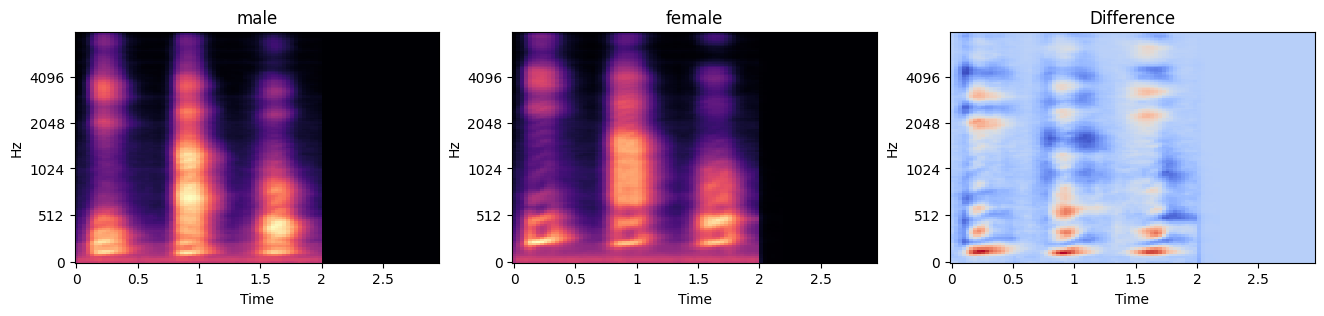

In [8]:
import librosa.display

# Creates a figure with two subplot
fig, axs = plt.subplots(1, 3, figsize=(16, 3))

# Plots mel spectrogram for male speakers
mels_male = np.mean(mels[df["sex_numeric"].eq(0)], axis=0)
librosa.display.specshow(mels_male, sr=sr, x_axis="time", y_axis="mel", ax=axs[0])
axs[0].set_title("male")

# Plots mel spectrogram for female speakers
mels_female = np.mean(mels[df["sex_numeric"].eq(1)], axis=0)
librosa.display.specshow(mels_female, sr=sr, x_axis="time", y_axis="mel", ax=axs[1])
axs[1].set_title("female")

# Plot gender differences
librosa.display.specshow(
    mels_male - mels_female, sr=sr, x_axis="time", y_axis="mel", ax=axs[2]
)
axs[2].set_title("Difference")
plt.show()

# Machine learning models

Goal: predict the age category based on the spectrogram features and dataset features

## Shallow ML Model

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 47 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   file                   108 non-null    object  
 1   label                  108 non-null    object  
 2   f0_mean                108 non-null    float64 
 3   f1_mean                108 non-null    float64 
 4   f2_mean                108 non-null    float64 
 5   f3_mean                108 non-null    float64 
 6   intensity_mean         108 non-null    float64 
 7   jitter_local           108 non-null    float64 
 8   shimmer_local          108 non-null    float64 
 9   f0_median              108 non-null    float64 
 10  f0_std                 108 non-null    float64 
 11  sample_name            108 non-null    object  
 12  attrac-voicesent-f     108 non-null    float64 
 13  attrac-voicesent-m     108 non-null    float64 
 14  attrac-voicesent-all   108 non-null    flo

In [10]:
# drop the columns that include -voicesent- in the name
df.drop(columns=[col for col in df.columns if "-voicesent-" in col], inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   file                  108 non-null    object  
 1   label                 108 non-null    object  
 2   f0_mean               108 non-null    float64 
 3   f1_mean               108 non-null    float64 
 4   f2_mean               108 non-null    float64 
 5   f3_mean               108 non-null    float64 
 6   intensity_mean        108 non-null    float64 
 7   jitter_local          108 non-null    float64 
 8   shimmer_local         108 non-null    float64 
 9   f0_median             108 non-null    float64 
 10  f0_std                108 non-null    float64 
 11  sample_name           108 non-null    object  
 12  attrac-voicevow-f     108 non-null    float64 
 13  attrac-voicevow-m     108 non-null    float64 
 14  attrac-voicevow-all   108 non-null    float64 
 15  mascfe

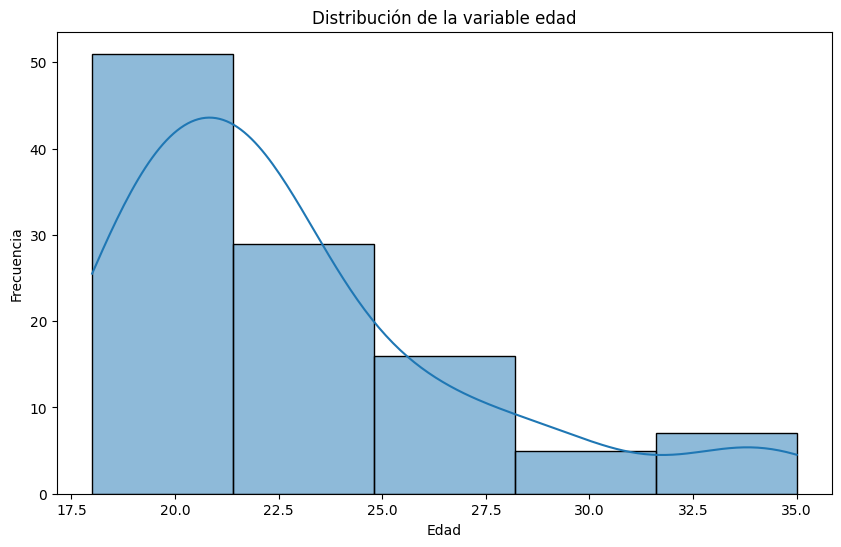

In [12]:
# Data Visualization of the age distribution

import seaborn as sns
# Plot the distribution of the age category

plt.figure(figsize=(10, 6))
sns.histplot(df["age"], bins=5, kde=True)
plt.title("Distribución de la variable edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

In [13]:
# create df_features
df_features = df.drop(columns=["file", "label", "sample_name", "sex", "age", "age_category"])
df_features.head()

,f0_mean,f1_mean,f2_mean,f3_mean,intensity_mean,jitter_local,shimmer_local,f0_median,f0_std,attrac-voicevow-f,...,domin-voicevow-m,domin-voicevow-all,health-voicevow-f,health-voicevow-m,health-voicevow-all,trust-voicevow-f,trust-voicevow-m,trust-voicevow-all,age_category_numeric,sex_numeric
0,122.322069,635.195806,1767.373862,3043.066290,58.393201,0.030243,0.089393,108.702278,49.581469,83.5,...,52.3,61.1,77.5,65.4,71.2,78.9,58.8,68.4,1,0.0
1,128.490284,609.408444,1657.802047,2873.230920,54.146626,0.022896,0.126083,112.885902,69.195320,67.7,...,68.7,70.4,74.7,77.0,75.9,59.5,66.1,62.8,1,0.0
2,244.779671,778.045595,1912.752299,3162.830370,57.474203,0.011711,0.105925,243.676692,17.893914,56.7,...,41.9,44.8,64.9,72.1,68.5,57.2,61.6,59.4,1,1.0
3,248.108167,647.491493,1760.853414,2908.456272,55.920847,0.021368,0.090407,243.117655,25.149248,44.2,...,49.1,46.8,61.6,58.7,60.0,52.9,51.3,52.0,1,1.0
4,244.347591,628.516425,1663.641613,3071.155453,52.288688,0.025479,0.133791,241.240378,18.864380,60.5,...,49.6,47.9,59.5,50.7,55.3,57.9,62.2,60.0,0,1.0


In [14]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   f0_mean               108 non-null    float64 
 1   f1_mean               108 non-null    float64 
 2   f2_mean               108 non-null    float64 
 3   f3_mean               108 non-null    float64 
 4   intensity_mean        108 non-null    float64 
 5   jitter_local          108 non-null    float64 
 6   shimmer_local         108 non-null    float64 
 7   f0_median             108 non-null    float64 
 8   f0_std                108 non-null    float64 
 9   attrac-voicevow-f     108 non-null    float64 
 10  attrac-voicevow-m     108 non-null    float64 
 11  attrac-voicevow-all   108 non-null    float64 
 12  mascfem-voicevow-f    108 non-null    float64 
 13  mascfem-voicevow-m    108 non-null    float64 
 14  mascfem-voicevow-all  108 non-null    float64 
 15  domin-

Select target variable and combine features with mels strength features

In [15]:
# Select target
target = "age_category_numeric"
y = df_features[target].values

#df_features.columns = df_features.columns.astype(str)

# Combine them with the mels strength features
X = pd.concat((df_features, pd.DataFrame(mels_strengths)), axis=1)

# Convert all columns names to string, otherwise the model will not work and will throw an error
X.columns = X.columns.astype(str)

print(f"Amount of features: {len(X.columns)}")

Amount of features: 154


In [16]:
# Display class distribution
print(f"Class distribution: \n{y.value_counts()}")

Class distribution: 
0    24
1    74
2    10
Name: count, dtype: int64


Target values are very imbalanced!

### Split the data into train, and test sets

In [17]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Split into train, test, and validation sets
x_tr, x_te, y_tr, y_te = train_test_split(
    X, y, train_size=0.8, shuffle=True, stratify=y, random_state=0
)

# Print dataset sizes
print(f"Train set size: {x_tr.shape}")
print(f"Train set class distribution: \n{y_tr.value_counts()}")
print(f"Test set size: {x_te.shape}")
print(f"Test set class distribution: \n{y_te.value_counts()}")


# Apply SMOTE only on the training set
smote = SMOTE(random_state=42)
x_tr_resampled, y_tr_resampled = smote.fit_resample(x_tr, y_tr)

# Print resampled training set size
print(f"Resampled Train set size: {x_tr_resampled.shape}")
print(f"Resampled Train set class distribution: \n{pd.Series(y_tr_resampled).value_counts().sort_index()}")

# Print dataset sizes
print(f"\nTrain set size: {x_tr.shape}")
print(f"Train set class distribution: \n{pd.Series(y_tr).value_counts().sort_index()}")
print(f"\nTest set size: {x_te.shape}")
print(f"Test set class distribution: \n{pd.Series(y_te).value_counts().sort_index()}")

Train set size: (86, 154)
Train set class distribution: 
0    19
1    59
2     8
Name: count, dtype: int64
Test set size: (22, 154)
Test set class distribution: 
0     5
1    15
2     2
Name: count, dtype: int64
Resampled Train set size: (177, 154)
Resampled Train set class distribution: 
0    59
1    59
2    59
Name: count, dtype: int64

Train set size: (86, 154)
Train set class distribution: 
0    19
1    59
2     8
Name: count, dtype: int64

Test set size: (22, 154)
Test set class distribution: 
0     5
1    15
2     2
Name: count, dtype: int64


In [18]:

# Log the size of the train and test sets
mlflow.log_param("train_set_size", x_tr_resampled.shape)
mlflow.log_param("train_set_class_distribution", pd.Series(y_tr_resampled).value_counts().sort_index())
mlflow.log_param("test_set_size", x_te.shape)
mlflow.log_param("test_set_class_distribution", pd.Series(y_te).value_counts().sort_index())


0     5
1    15
2     2
Name: count, dtype: int64

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, QuantileTransformer, RobustScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
import numpy as np

# Define the categorical and numerical columns
categorical_features = ["age_category_numeric"]
numerical_features = [col for col in df_features.columns if col != "age_category_numeric"]  # Exclude the categorical column

# Create the ColumnTransformer to handle preprocessing for both types of features
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(sparse_output=False, drop="first"), categorical_features),  # One-Hot Encoding for categorical columns
        ("num", RobustScaler(), numerical_features),  # Scaling for numerical columns
    ]
)

# Create the pipeline with preprocessing and model steps
pipe = Pipeline(
    [
        ("preprocessor", preprocessor),  # Preprocessing step
        ("pca", PCA()),                  # Dimensionality reduction with PCA
        ("logreg", LogisticRegression(class_weight="balanced")),  # Logistic Regression model
    ]
)

# Create the grid for hyperparameter tuning
grid = {
    "preprocessor__num": [RobustScaler(), PowerTransformer()],  # Test different scalers for numerical data
    "pca": [None, PCA(0.99)],  # PCA with 99% variance or no PCA at all
    "logreg__C": np.logspace(-4, 3, num=20),  # Regularization strength for Logistic Regression
}

# Create GridSearchCV object for hyperparameter tuning with cross-validation
grid_cv = GridSearchCV(pipe, grid, cv=StratifiedKFold(n_splits=4), return_train_score=True, verbose=1)

In [20]:
mlflow.log_param("grid_search_parameters", grid)

{'preprocessor__num': [RobustScaler(), PowerTransformer()],
 'pca': [None, PCA(n_components=0.99)],
 'logreg__C': array([1.00000000e-04, 2.33572147e-04, 5.45559478e-04, 1.27427499e-03,
        2.97635144e-03, 6.95192796e-03, 1.62377674e-02, 3.79269019e-02,
        8.85866790e-02, 2.06913808e-01, 4.83293024e-01, 1.12883789e+00,
        2.63665090e+00, 6.15848211e+00, 1.43844989e+01, 3.35981829e+01,
        7.84759970e+01, 1.83298071e+02, 4.28133240e+02, 1.00000000e+03])}

In [21]:
# Train GridSearchCV
model = grid_cv.fit(x_tr, y_tr)

Fitting 4 folds for each of 80 candidates, totalling 320 fits


In [22]:
# Log cross-validation metrics
cv_results = model.cv_results_
for i in range(len(cv_results['params'])):
    with mlflow.start_run(nested=True):
        mlflow.log_params(cv_results['params'][i])
        mlflow.log_metric("mean_test_score", 
                         cv_results['mean_test_score'][i])

🏃 View run capricious-jay-603 at: http://localhost:5000/#/experiments/40/runs/8bc83ee55fcb404e875be10dd79a9b35
🧪 View experiment at: http://localhost:5000/#/experiments/40
🏃 View run casual-kite-842 at: http://localhost:5000/#/experiments/40/runs/51a551d64db741829f1c2265d749bc7e
🧪 View experiment at: http://localhost:5000/#/experiments/40
🏃 View run debonair-auk-390 at: http://localhost:5000/#/experiments/40/runs/ceca4fa8764b4ae08c4d1bc33d03b5b7
🧪 View experiment at: http://localhost:5000/#/experiments/40
🏃 View run victorious-slug-699 at: http://localhost:5000/#/experiments/40/runs/07fa0b45580641459e5e11ad439c03e4
🧪 View experiment at: http://localhost:5000/#/experiments/40
🏃 View run beautiful-moth-309 at: http://localhost:5000/#/experiments/40/runs/6a167966cfa34d82b52f3f4ea59e5130
🧪 View experiment at: http://localhost:5000/#/experiments/40
🏃 View run nervous-newt-902 at: http://localhost:5000/#/experiments/40/runs/f6b10f44c73d46f9a0a1d9d37e92678d
🧪 View experiment at: http://localh

In [23]:
from mlflow.models.signature import infer_signature

 # Infer model signature
signature = infer_signature(x_tr, model.predict(x_tr))

# Register the model
mlflow.sklearn.log_model(sk_model=model, artifact_path="model", signature=signature)

/Users/antonellaschiavoni/Documents/Antonella/tesis-ciencia-de-datos/venv/lib/python3.10/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


In [24]:
mlflow.log_metric("best_score", model.best_score_)

# For logging the best parameters, you need to convert them into a string or log them individually
best_params = model.best_params_
for param, value in best_params.items():
    mlflow.log_param(param, value)

mlflow.log_param("best_estimator", str(model.best_estimator_))

"Pipeline(steps=[('preprocessor',\n                 ColumnTransformer(transformers=[('cat',\n                                                  OneHotEncoder(drop='first',\n                                                                sparse_output=False),\n                                                  ['age_category_numeric']),\n                                                 ('num', RobustScaler(),\n                                                  ['f0_mean', 'f1_mean',\n                                                   'f2_mean', 'f3_mean',\n                                                   'intensity_mean',\n                                                   'jitter_local',\n                                                   'shimmer_local', 'f0_median',\n                                                   'f0_std',\n                                                   'attrac-voicevow-f',\n                                                   'attrac-voicevow-m',\n             

In [25]:
# Select the columns we are interested in
col_of_interest = [
    "param_preprocessor__num",  # Instead of "param_scaler"
    "param_pca",
    "param_logreg__C",
    "mean_test_score",
    "mean_train_score",
    "std_test_score",
    "std_train_score",
]

# Collect results in a DataFrame
cv_results = pd.DataFrame(grid_cv.cv_results_)
cv_results = cv_results[col_of_interest]

# Show the dataframe sorted according to our performance metric
cv_results.sort_values("mean_test_score", ascending=False)

,param_preprocessor__num,param_pca,param_logreg__C,mean_test_score,mean_train_score,std_test_score,std_train_score
60,RobustScaler(),None,33.598183,0.988636,1.000000,0.019682,0.000000
64,RobustScaler(),None,78.475997,0.988636,1.000000,0.019682,0.000000
52,RobustScaler(),None,6.158482,0.988636,1.000000,0.019682,0.000000
72,RobustScaler(),None,428.133240,0.988636,1.000000,0.019682,0.000000
56,RobustScaler(),None,14.384499,0.988636,1.000000,0.019682,0.000000
...,...,...,...,...,...,...,...
11,PowerTransformer(),PCA(n_components=0.99),0.000546,0.291126,0.531130,0.024939,0.070062
5,PowerTransformer(),None,0.000234,0.279221,0.527284,0.006494,0.072469
1,PowerTransformer(),None,0.000100,0.279221,0.519531,0.006494,0.065881
7,PowerTransformer(),PCA(n_components=0.99),0.000234,0.267316,0.527284,0.017684,0.069976


In [26]:
grid


{'preprocessor__num': [RobustScaler(), PowerTransformer()],
 'pca': [None, PCA(n_components=0.99)],
 'logreg__C': array([1.00000000e-04, 2.33572147e-04, 5.45559478e-04, 1.27427499e-03,
        2.97635144e-03, 6.95192796e-03, 1.62377674e-02, 3.79269019e-02,
        8.85866790e-02, 2.06913808e-01, 4.83293024e-01, 1.12883789e+00,
        2.63665090e+00, 6.15848211e+00, 1.43844989e+01, 3.35981829e+01,
        7.84759970e+01, 1.83298071e+02, 4.28133240e+02, 1.00000000e+03])}

### Print Training and Test Curves

In [27]:
grid

{'preprocessor__num': [RobustScaler(), PowerTransformer()],
 'pca': [None, PCA(n_components=0.99)],
 'logreg__C': array([1.00000000e-04, 2.33572147e-04, 5.45559478e-04, 1.27427499e-03,
        2.97635144e-03, 6.95192796e-03, 1.62377674e-02, 3.79269019e-02,
        8.85866790e-02, 2.06913808e-01, 4.83293024e-01, 1.12883789e+00,
        2.63665090e+00, 6.15848211e+00, 1.43844989e+01, 3.35981829e+01,
        7.84759970e+01, 1.83298071e+02, 4.28133240e+02, 1.00000000e+03])}

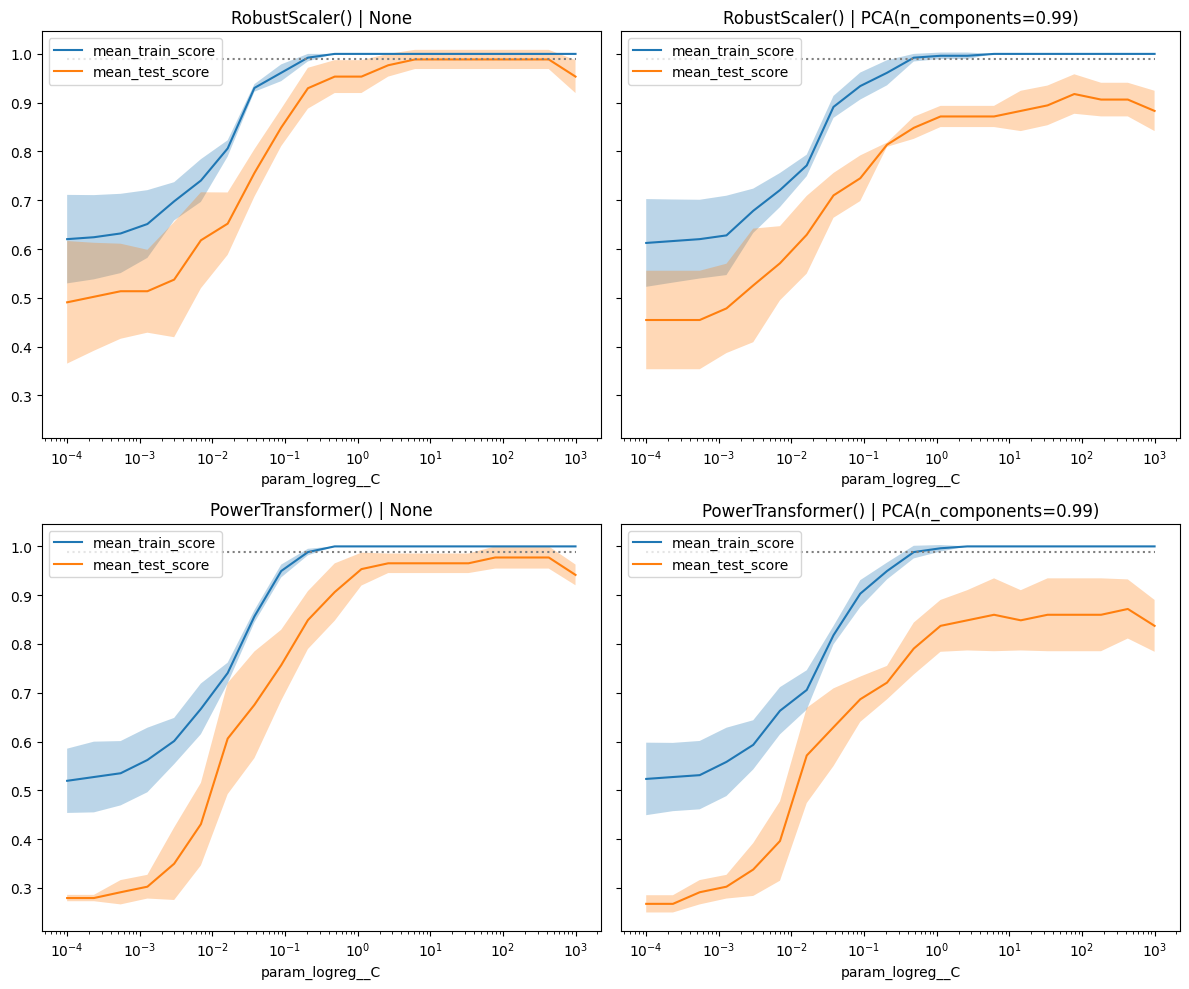

In [28]:
from itertools import product

# Establish combinations of different hyperparameters
combinations = list(product(grid["preprocessor__num"], grid["pca"]))

# Creates a figure with multiple subplot
fig, axs = plt.subplots(
    len(grid["preprocessor__num"]), len(grid["pca"]), figsize=(12, 10), sharey=True)

# Extract useful information about max performance
max_score = cv_results["mean_test_score"].max()
c_values = cv_results["param_logreg__C"]

# Loop through the subplots and populate them
for i, (s, p) in enumerate(combinations):
    # Select subplot relevant grid search results
    mask = np.logical_and(
        cv_results["param_pca"].astype("str") == str(p),
        cv_results["param_preprocessor__num"].astype("str") == str(s),  # Fixed column name
    )
    df_cv = cv_results[mask].sort_values("param_logreg__C").set_index("param_logreg__C")


    # Select relevant axis
    ax = axs.flatten()[i]

    # Plot train and test curves
    df_cv[["mean_train_score", "mean_test_score"]].plot(
        logx=True, title=f"{s} | {p}", ax=ax)
    ax.fill_between(
        df_cv.index,
        df_cv["mean_train_score"] - df_cv["std_train_score"],
        df_cv["mean_train_score"] + df_cv["std_train_score"],
        alpha=0.3,)
    ax.fill_between(
        df_cv.index,
        df_cv["mean_test_score"] - df_cv["std_test_score"],
        df_cv["mean_test_score"] + df_cv["std_test_score"],
        alpha=0.3,)

    # Plot best performance metric as dotted line
    ax.hlines(
        max_score, c_values.min(), c_values.max(), color="gray", linestyles="dotted")

plt.tight_layout()
plt.show()

In [29]:
# Log the plot
mlflow.log_figure(fig, "grid_search_plot.png")


In [30]:
# Compute score of the best model on the withheld test set
best_clf = model.best_estimator_
best_clf.score(x_te, y_te)

1.0

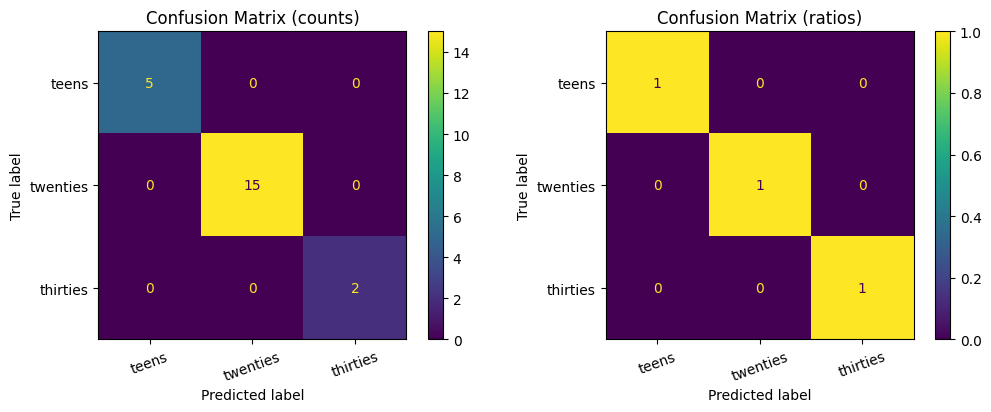

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion_matrices(y_true, y_pred):
    # Create two subplots
    f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Dynamically set labels based on unique classes
    unique_classes = np.unique(np.concatenate([y_true, y_pred]))
    labels = ["teens", "twenties", "thirties", "fourties", "fifties", "sixties"][:len(unique_classes)]

    # Plots the standard confusion matrix
    ax1.set_title("Confusion Matrix (counts)")
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=labels, xticks_rotation=20, ax=ax1)

    # Plots the normalized confusion matrix
    ax2.set_title("Confusion Matrix (ratios)")
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=labels, xticks_rotation=20, ax=ax2,
        normalize="true")

    # Log the confusion matrix
    mlflow.log_figure(f, "confusion_matrix.png")
    
    plt.show()



# Compute test set predictions
predictions = best_clf.predict(x_te)

# Plot confusion matrices
plot_confusion_matrices(y_te, predictions)



In [32]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# Realiza predicciones en el conjunto de prueba
y_pred = grid_cv.best_estimator_.predict(x_te)

# Calcula las métricas
print("Classification Report:")
print(classification_report(y_te, y_pred))

# Si quieres calcularlas individualmente:
precision = precision_score(y_te, y_pred, average='weighted')  # Cambia 'weighted' según tus necesidades
recall = recall_score(y_te, y_pred, average='weighted')
f1 = f1_score(y_te, y_pred, average='weighted')

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

mlflow.log_metric("precision", precision)
mlflow.log_metric("recall", recall)
mlflow.log_metric("f1_score", f1)

mlflow.log_param("best_estimator", str(model.best_estimator_))
mlflow.log_param("best_score", model.best_score_)
mlflow.log_param("grid_search_parameters", grid)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00         2

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22

Precision: 1.00
Recall: 1.00
F1-Score: 1.00


{'preprocessor__num': [RobustScaler(), PowerTransformer()],
 'pca': [None, PCA(n_components=0.99)],
 'logreg__C': array([1.00000000e-04, 2.33572147e-04, 5.45559478e-04, 1.27427499e-03,
        2.97635144e-03, 6.95192796e-03, 1.62377674e-02, 3.79269019e-02,
        8.85866790e-02, 2.06913808e-01, 4.83293024e-01, 1.12883789e+00,
        2.63665090e+00, 6.15848211e+00, 1.43844989e+01, 3.35981829e+01,
        7.84759970e+01, 1.83298071e+02, 4.28133240e+02, 1.00000000e+03])}

In [33]:
#log duration of the experiment
mlflow.log_param("duration", time.time() - start_time)

mlflow.end_run(status="FINISHED")

🏃 View run Age Prediction Experiment - Voice Vowels - V1 at: http://localhost:5000/#/experiments/0/runs/81e275b76ef6485182b08f2582fcf66a
🧪 View experiment at: http://localhost:5000/#/experiments/0
